# Correlation Analysis and Multicollinearity Assessment

## Overview

This notebook combines the harmonized datasets from all selected SAMBBA research flights to investigate the relationships between aerosol physicochemical properties, optical measurements and supporting atmospheric variables. It also evaluates multicollinearity among the predictor variables prior to the regression analyses presented in the manuscript.

## Workflow

1. Load and preprocess all selected research flights.
2. Synchronize measurements from the different instruments using common timestamps.
3. Merge the individual flights into a single analysis dataset.
4. Compute correlation matrices for the selected variables.
5. Quantify multicollinearity using the Variance Inflation Factor (VIF).
6. Generate publication-quality figures summarizing the correlation structure of the dataset.

## Inputs

- Harmonized flight datasets generated by the preprocessing workflow.
- Matched measurements from the FAAM core, AMS, SP2 and nephelometer instruments.

## Outputs

- Combined analysis dataset containing all selected flights.
- Correlation matrix used for exploratory data analysis.
- Variance Inflation Factor (VIF) values and corresponding visualization.

## Requirements

This notebook assumes that the preprocessing workflow has already been executed and that the processed datasets are available within the repository directory structure.


In [17]:
# Import the libraries required for data processing, statistical analysis and visualization.
import re
import numpy as np
import xarray as xr
import pandas as pd
from flights_io_commented  import get_matched_flights
from flight_processing_commented import process_flight
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns



In [18]:
# Define the location of the SAMBBA flight archive and identify the flights to be included in the analysis.
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"

dirs =  [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b748-oct-02", 
    "b749-oct-03", 
]

flights = get_matched_flights(base_dir, dirs)

for flight in flights:
    print(flight.core_cloud)

Matched flights: 10
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b734-sep-18/core_processed/core-cloud-phy_faam_20120918_v500_r0_b734.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b737-sep-20/core_processed/core-cloud-phy_faam_20120920_v500_r0_b737.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/core_processed/core-cloud-phy_faam_20120923_v500_r0_b739.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b742-sep-27/core_processed/core-cloud-phy_faam_20120927_v500_r0_b742.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b743-sep-27/core_processed/core-cloud-phy_faam_20120927_v500_r0_b743.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b744-sep-28/core_processed/core-cloud-phy_faam_20120928_v500_r0_b744.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b745-sep-28/core_processed/core-cloud-phy_faam_20120928_v500_r0_b745.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2

In [19]:
# Process each research flight individually, synchronize measurements from the different instruments and store the variables required for the combined analysis.
results = []

for flight in flights:
    out = process_flight(flight)

    # Retain only the timestamps shared by the FAAM core, AMS and SP2
    # datasets. Restricting the analysis to concurrent measurements
    # ensures that all variables describe the same atmospheric conditions.
    common_times = np.intersect1d(out.core.data_point.values, out.ams.time.values)
    # Then intersect with SP2
    common_times = np.intersect1d(common_times, out.sp2.time.values)
    
    
    core_file_matched = out.core.sel(data_point=common_times)
    ams_resampled_matched = out.ams.sel(time=common_times)
    sp2_resampled_matched = out.sp2.sel(time=common_times)
    resampled_neph_matched = out.neph.sel(time=common_times)
    Dg_aligned_matched = out.Dgs.reindex(pd.to_datetime(common_times), method="nearest")
    PM_ratio_matched = out.PM_ratio.sel(PCAS2TSPM = common_times)
    
    # Core file variables
    Height = core_file_matched['GPS_ALT'].values.squeeze()
    Lon = core_file_matched['LON_GPS'].values.squeeze()
    Lat = core_file_matched['LAT_GPS'].values.squeeze()
    CO_conc_matched = core_file_matched['CO_AERO'].values.squeeze()
    PSAP_matched = core_file_matched['PSAP_LIN'].values.squeeze()

    # Cabin conditions
    CAB_PRES = core_file_matched["CAB_PRES"].values.squeeze()      # hPa
    CAB_TEMP = core_file_matched["CAB_TEMP"].values.squeeze() + 273.15  # K

    #Neph file variables
    TSC_blue = resampled_neph_matched["TSC_BLUU"].values.squeeze()
    TSC_green = resampled_neph_matched["TSC_GRNU"].values.squeeze()
    TSC_red = resampled_neph_matched["TSC_REDU"].values.squeeze()

    # STP reference
    P_STP = 1013.25   # hPa
    T_STP = 273.15    # K

    conversion_factor = (CAB_PRES / P_STP) * (T_STP / CAB_TEMP)

    #Sp2 file variables
    BC = sp2_resampled_matched.values * conversion_factor  # Convert to ATP conditions
    #AMS file variables
    ORG = ams_resampled_matched['ORG'].values * conversion_factor  # Convert to ATP conditions
    ORG_unc = ams_resampled_matched['ORG_uncertainty'].values * conversion_factor  # Convert to ATP conditions
    SO4 = ams_resampled_matched['SO4'].values * conversion_factor  # Convert to ATP conditions
    SO4_unc = ams_resampled_matched['SO4_uncertainty'].values * conversion_factor  # Convert to ATP conditions
    NH4 = ams_resampled_matched['NH4'].values * conversion_factor  # Convert to ATP conditions
    NH4_unc = ams_resampled_matched['NH4_uncertainty'].values * conversion_factor  # Convert to ATP conditions
    NO3 = ams_resampled_matched['NO3'].values * conversion_factor  # Convert to ATP conditions
    NO3_unc = ams_resampled_matched['NO3_uncertainty'].values * conversion_factor  # Convert to ATP conditions
    AS = ams_resampled_matched['NH4_2SO4'].values * conversion_factor  # Convert to ATP conditions
    AN = ams_resampled_matched['NH4NO3'].values * conversion_factor  # Convert to ATP conditions
    #PCASP variables
    Dg = Dg_aligned_matched
    ratio_pm = PM_ratio_matched
    
    
    # Extract the flight number (b###) from the file path
    match = re.search(r'b\d{3}', flight.core)  # Looks for 'b' followed by 3 digits
    flight_number = match.group(0) if match else "Unknown"
    
    results.append({
        'ORG': ORG,
        'BC': BC,
        'SO4': SO4,
        'NH4': NH4,
        'NO3': NO3,
        'AS': AS,
        'AN': AN,
        'TSC_blue':TSC_blue,
        'TSC_green':TSC_green,
        'TSC_red':TSC_red,
        'ABS_PSAP':PSAP_matched,
        'DG_aligned': Dg,
        'PM_ratio': ratio_pm,
        'CO': CO_conc_matched,
        'ALT' : Height,
        'LON': Lon,
        'LAT': Lat,
        'flight': flight_number
    })

In [20]:
# Merge the processed observations from all flights into a single DataFrame for the statistical analyses.
# Combine all flight data
combined_data = []
for entry in results:
    try:
        df = pd.DataFrame({
            'TSC_blue': entry['TSC_blue'],
            'TSC_green': entry['TSC_green'],
            'TSC_red': entry['TSC_red'],
            'ABS_PSAP':entry['ABS_PSAP'],
            'rBC': entry['BC'],
            'SO4': entry['SO4'],
            'NH4': entry['NH4'],
            'NO3': entry['NO3'],
            'AS': entry['AS'],
            'AN': entry['AN'],
            'OA': entry['ORG'],
            'DG': entry['DG_aligned'],
            'PM_coarse': entry['PM_ratio'],
            'ALT' : entry['ALT'],
            'LON': entry['LON'],
            'LAT': entry['LAT'],
            'CO': entry['CO'],
            'Flight': entry['flight']
        })

        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all = pd.concat(combined_data)
df_clean = df_all.replace([np.inf, -np.inf], np.nan).dropna()

In [21]:
# Define the variable groups used throughout the correlation and multicollinearity analyses.
scattering_vars = ['TSC_green']
absorption_vars = ['ABS_PSAP']
chemistry_vars = ['rBC', 'SO4', 'NH4', 'NO3', 'OA']
other_vars = ['CO','PM_coarse']

In [22]:
# Compute the Variance Inflation Factor (VIF) for the aerosol physicochemical variables to quantify multicollinearity prior to the regression analyses.
X = df_clean[chemistry_vars]
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

  Variable        VIF
0      rBC   1.769003
1      SO4  13.028052
2      NH4  33.387065
3      NO3  10.162598
4       OA   2.881276


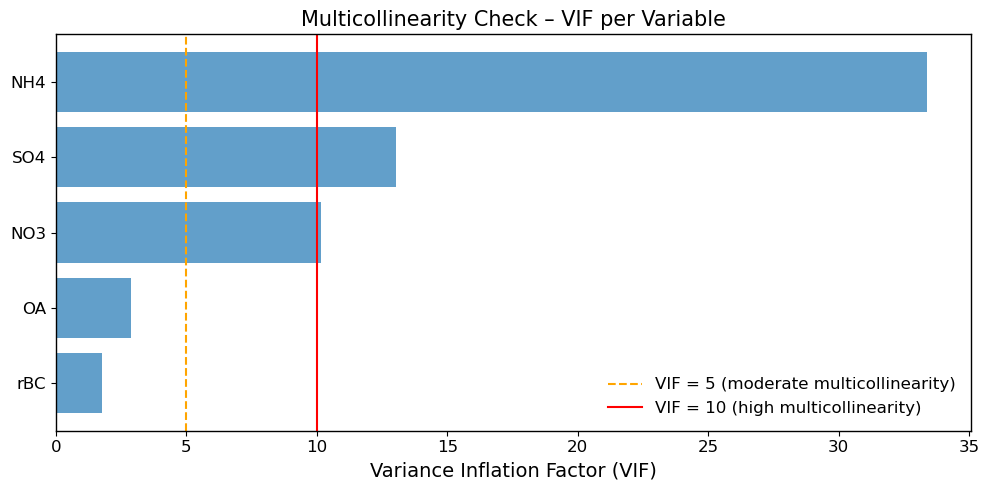

In [23]:
# Visualize the VIF values using a publication-quality horizontal bar chart.
# Sort by VIF for better visualization
vif_sorted = vif.sort_values(by="VIF", ascending=True)

# Font sizes
label_fs = 14
tick_fs = 12
legend_fs = 12
title_fs = 15

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    vif_sorted["Variable"],
    vif_sorted["VIF"],
    alpha=0.7
)

# Threshold lines
ax.axvline(
    5,
    linestyle="--",
    color="orange",
    label="VIF = 5 (moderate multicollinearity)"
)
ax.axvline(
    10,
    linestyle="-",
    color="red",
    label="VIF = 10 (high multicollinearity)"
)

# Labels and title
ax.set_xlabel("Variance Inflation Factor (VIF)", fontsize=label_fs)
ax.set_title("Multicollinearity Check – VIF per Variable", fontsize=title_fs)

# Tick labels
ax.tick_params(axis="both", labelsize=tick_fs)

# Legend
ax.legend(fontsize=legend_fs, frameon=False)

plt.tight_layout()
plt.show()

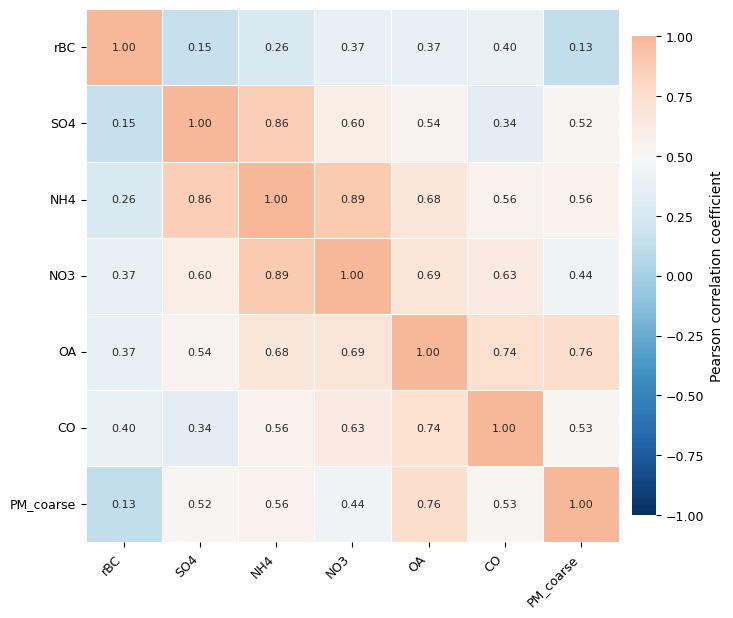

In [24]:
# Configure the plotting style and generate the correlation matrix used in the manuscript.
# -----------------------------------------------
# Style for publication figures
# -----------------------------------------------
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.0,
})

# -----------------------------------------------
# Correlation matrix
# -----------------------------------------------
corr_df = df_clean[chemistry_vars + other_vars]

corr_matrix = corr_df.corr(method="pearson")

annot_matrix = corr_matrix.round(2)

# -----------------------------------------------
# Plot
# -----------------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 6.5))

sns.heatmap(
    corr_matrix,
    annot=annot_matrix,
    fmt=".2f",
    cmap="RdBu_r",           # preferred diverging palette
    vmin=-1,
    vmax=1,
    center=0.5,
    square=True,
    linewidths=0.4,
    linecolor="white",
    annot_kws={
        "size": 8
    },
    cbar_kws={
        "label": "Pearson correlation coefficient",
        "shrink": 0.85,
        "pad": 0.02
    },
    ax=ax
)

# Axis formatting
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0
)

plt.tight_layout()

plt.show()